In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

Mounted at /content/drive


In [ ]:
df_mysql = pd.read_csv('/content/drive/MyDrive/Projeto_Banco_Dados/estatisticas_consultas_mysql.csv')
df_postgres = pd.read_csv('/content/drive/MyDrive/Projeto_Banco_Dados/estatisticas_consultas_postgresql.csv')

df_mysql['SGBD'] = 'MySQL'
df_postgres['SGBD'] = 'PostgreSQL'

df_mysql['consulta_base'] = df_mysql['tipo_de_consulta'].str.replace('_MySQL', '', regex=False)
df_postgres['consulta_base'] = df_postgres['tipo_de_consulta'].str.replace('_PostgreSQL', '', regex=False)

df_projeto = pd.concat([df_mysql, df_postgres], ignore_index=True)
df_projeto.head()

,tipo_de_consulta,contagem_tempo,media_tempo_segundos,desvio_padrao_tempo,tempo_minimo_segundos,tempo_maximo_segundos,mediana_tempo_segundos,media_ram_kb,desvio_padrao_ram,ram_minima_kb,ram_maxima_kb,mediana_ram_kb,SGBD,consulta_base
0,BUSCA_B_PLUS_AGRUPAMENTOS_MySQL,20,473.991899,16.112701,451.555429,492.473730,474.134759,1664943.2,1658.803424,1663320,1666560,1664944.0,MySQL,BUSCA_B_PLUS_AGRUPAMENTOS
1,BUSCA_B_PLUS_COM_LIKE_MySQL,20,29.070094,2.451771,25.917605,31.549464,30.425462,859654.8,7984.502052,846464,866560,863320.0,MySQL,BUSCA_B_PLUS_COM_LIKE
2,BUSCA_B_PLUS_COM_SUBCONSULTAS_MySQL,20,9.517990,1.353631,5.791800,10.694186,9.872428,859654.8,7984.502052,846464,866560,863320.0,MySQL,BUSCA_B_PLUS_COM_SUBCONSULTAS
3,BUSCA_B_PLUS_INDEX_NAO_IDEAL_AGRUPAMENTOS_MySQL,20,477.857007,16.935024,451.908930,498.383207,477.859033,1664943.2,1658.803424,1663320,1666560,1664944.0,MySQL,BUSCA_B_PLUS_INDEX_NAO_IDEAL_AGRUPAMENTOS
4,BUSCA_B_PLUS_INDEX_NAO_IDEAL_CHAVE_PRIMARIA_MySQL,20,0.035895,0.011158,0.025566,0.062799,0.032928,33337.3,2074.087881,30280,35896,33361.0,MySQL,BUSCA_B_PLUS_INDEX_NAO_IDEAL_CHAVE_PRIMARIA


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.container as container_mod

sns.set_theme(style="whitegrid")

def plotar_boxplots_categoria(lista_consultas, titulo_grafico, nome_eixo_x):
    df_filtrado = df_projeto[df_projeto['consulta_base'].isin(lista_consultas)]

    if df_filtrado.empty:
        print(f"Aviso: Nenhuma consulta encontrada para a categoria '{titulo_grafico}'.")
        return

    bxp_stats = []
    positions = []

    for idx, q in enumerate(lista_consultas):
        # MySQL
        row_my = df_filtrado[(df_filtrado['consulta_base'] == q) & (df_filtrado['SGBD'] == 'MySQL')]
        if not row_my.empty:
            row = row_my.iloc[0]
            bxp_stats.append({
                'whislo': row['tempo_minimo_segundos'],
                'q1': max(row['tempo_minimo_segundos'], row['media_tempo_segundos'] - row['desvio_padrao_tempo']),
                'med': row['mediana_tempo_segundos'],
                'q3': min(row['tempo_maximo_segundos'], row['media_tempo_segundos'] + row['desvio_padrao_tempo']),
                'whishi': row['tempo_maximo_segundos'],
                'mean': row['media_tempo_segundos'],
                'fliers': []
            })
            positions.append(idx * 3 + 1)

        # PostgreSQL
        row_pg = df_filtrado[(df_filtrado['consulta_base'] == q) & (df_filtrado['SGBD'] == 'PostgreSQL')]
        if not row_pg.empty:
            row = row_pg.iloc[0]
            bxp_stats.append({
                'whislo': row['tempo_minimo_segundos'],
                'q1': max(row['tempo_minimo_segundos'], row['media_tempo_segundos'] - row['desvio_padrao_tempo']),
                'med': row['mediana_tempo_segundos'],
                'q3': min(row['tempo_maximo_segundos'], row['media_tempo_segundos'] + row['desvio_padrao_tempo']),
                'whishi': row['tempo_maximo_segundos'],
                'mean': row['media_tempo_segundos'],
                'fliers': []
            })
            positions.append(idx * 3 + 2)

    fig, ax = plt.subplots(figsize=(13, 7))

    artists = ax.bxp(
        bxp_stats,
        positions=positions,
        widths=0.6,
        showmeans=True,
        patch_artist=True,
        meanprops={'markerfacecolor': 'white', 'markeredgecolor': 'black', 'marker': 'D', 'markersize': 7}
    )

    for i, box in enumerate(artists['boxes']):
        if i % 2 == 0:
            box.set(facecolor='#66c2a5', alpha=0.85, edgecolor='#404040')
        else:
            box.set(facecolor='#fc8d62', alpha=0.85, edgecolor='#404040')

    for median in artists['medians']:
        median.set(color='#d95f02', linewidth=2)

    for whisker in artists['whiskers']:
        whisker.set(color='#7570b3', linestyle='--', linewidth=1.2)
    for cap in artists['caps']:
        cap.set(color='#7570b3', linewidth=1.2)

    ax.set_xticks([idx * 3 + 1.5 for idx in range(len(lista_consultas))])
    ax.set_xticklabels(lista_consultas, rotation=20, ha='right', fontsize=9.5)

    ax.set_title(titulo_grafico, fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel(nome_eixo_x, fontsize=11, labelpad=10)
    ax.set_ylabel('Tempo de Execução (segundos)', fontsize=11)

    legend_elements = [
        Patch(facecolor='#66c2a5', edgecolor='#404040', label='MySQL'),
        Patch(facecolor='#fc8d62', edgecolor='#404040', label='PostgreSQL'),
        Line2D([0], [0], color='#d95f02', lw=2, label='Linha Central: Mediana'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='white', markeredgecolor='black', markersize=8, label=r'Marcador $\diamond$: Média'),
        Line2D([0], [0], color='#7570b3', linestyle='--', lw=1.2, label=r'Limites da Caixa: $\pm$ Desvio Padrão')
    ]
    ax.legend(handles=legend_elements, title='Componentes e SGBD', loc='upper right', frameon=True, shadow=True)
    ax.grid(True, linestyle=':', alpha=0.6, axis='y')
    plt.tight_layout()
    plt.show()


def plotar_boxplots_ram_categoria(lista_consultas, titulo_grafico, nome_eixo_x):
    df_filtrado = df_projeto[df_projeto['consulta_base'].isin(lista_consultas)]

    if df_filtrado.empty:
        print(f"Aviso: Nenhuma consulta encontrada para a categoria '{titulo_grafico}'.")
        return

    bxp_stats = []
    positions = []

    for idx, q in enumerate(lista_consultas):
        # MySQL RAM
        row_my = df_filtrado[(df_filtrado['consulta_base'] == q) & (df_filtrado['SGBD'] == 'MySQL')]
        if not row_my.empty:
            row = row_my.iloc[0]
            ram_min = row['ram_minima_kb'] / 1024
            ram_max = row['ram_maxima_kb'] / 1024
            ram_media = row['media_ram_kb'] / 1024
            ram_desvio = row['desvio_padrao_ram'] / 1024
            ram_mediana = row['mediana_ram_kb'] / 1024

            bxp_stats.append({
                'whislo': ram_min,
                'q1': max(ram_min, ram_media - ram_desvio),
                'med': ram_mediana,
                'q3': min(ram_max, ram_media + ram_desvio),
                'whishi': ram_max,
                'mean': ram_media,
                'fliers': []
            })
            positions.append(idx * 3 + 1)

        # PostgreSQL RAM
        row_pg = df_filtrado[(df_filtrado['consulta_base'] == q) & (df_filtrado['SGBD'] == 'PostgreSQL')]
        if not row_pg.empty:
            row = row_pg.iloc[0]
            ram_min = row['ram_minima_kb'] / 1024
            ram_max = row['ram_maxima_kb'] / 1024
            ram_media = row['media_ram_kb'] / 1024
            ram_desvio = row['desvio_padrao_ram'] / 1024
            ram_mediana = row['mediana_ram_kb'] / 1024

            bxp_stats.append({
                'whislo': ram_min,
                'q1': max(ram_min, ram_media - ram_desvio),
                'med': ram_mediana,
                'q3': min(ram_max, ram_media + ram_desvio),
                'whishi': ram_max,
                'mean': ram_media,
                'fliers': []
            })
            positions.append(idx * 3 + 2)

    fig, ax = plt.subplots(figsize=(13, 7))

    artists = ax.bxp(
        bxp_stats,
        positions=positions,
        widths=0.6,
        showmeans=True,
        patch_artist=True,
        meanprops={'markerfacecolor': 'white', 'markeredgecolor': 'black', 'marker': 'D', 'markersize': 7}
    )

    for i, box in enumerate(artists['boxes']):
        if i % 2 == 0:
            box.set(facecolor='#b3cde3', alpha=0.9, edgecolor='#404040')
        else:
            box.set(facecolor='#fbb4ae', alpha=0.9, edgecolor='#404040')


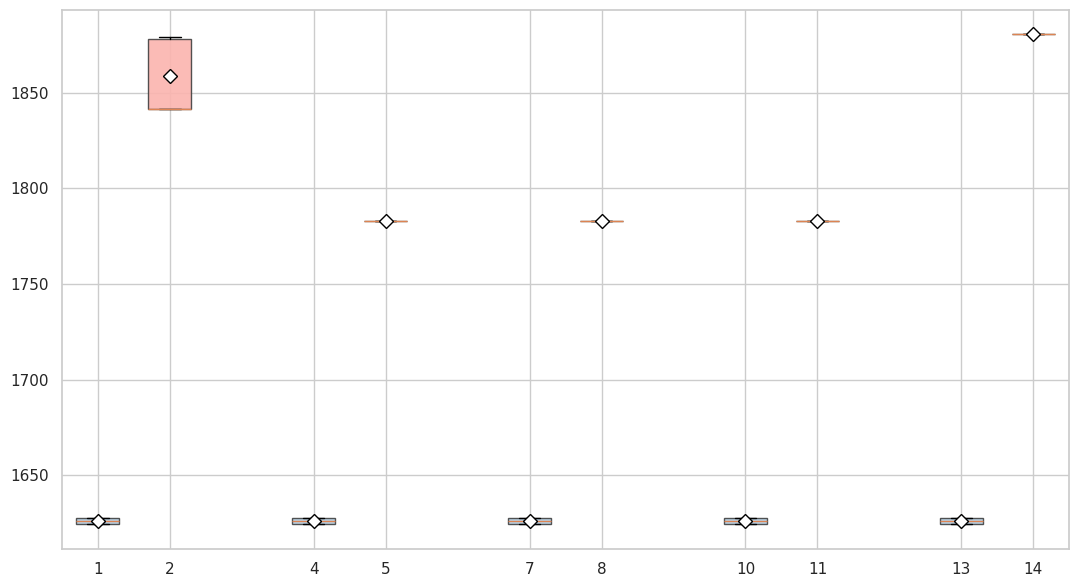

In [24]:
plotar_boxplots_ram_categoria(cat_agrupamentos, "RAM em Agrupamentos (Group By)", "Cenários de Agrupamento")

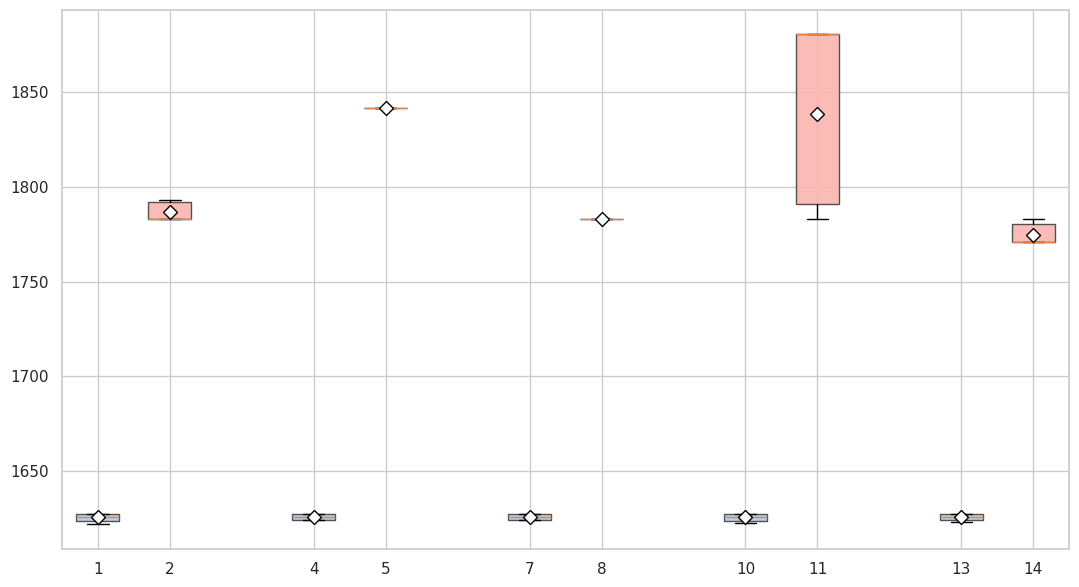

In [25]:
plotar_boxplots_ram_categoria(cat_juncoes, "RAM em Junções (Joins)", "Cenários de Junção")

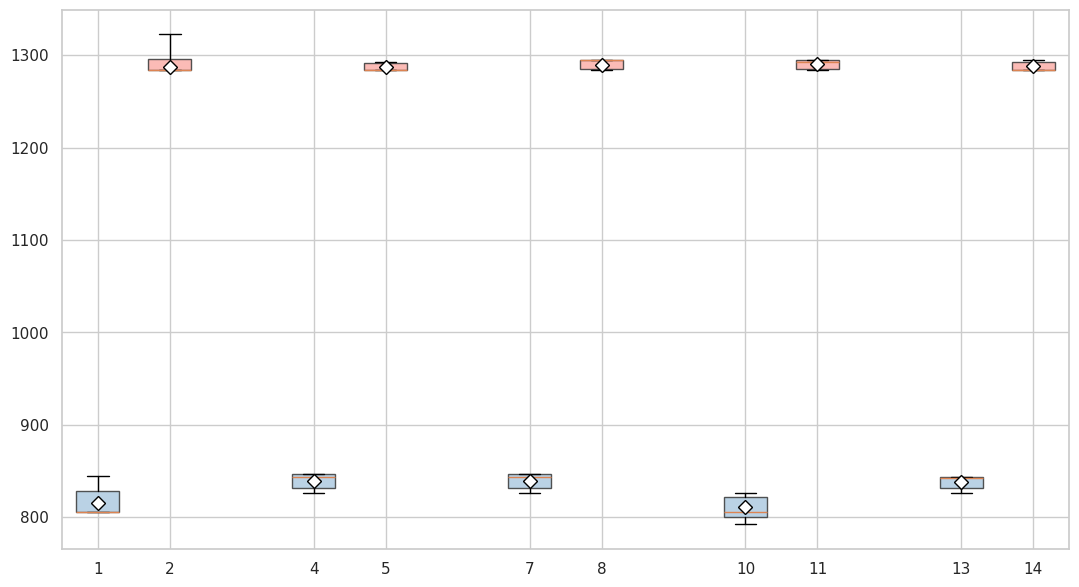

In [26]:
plotar_boxplots_ram_categoria(cat_like, "RAM em Filtros Textuais (LIKE)", "Cenários com LIKE")

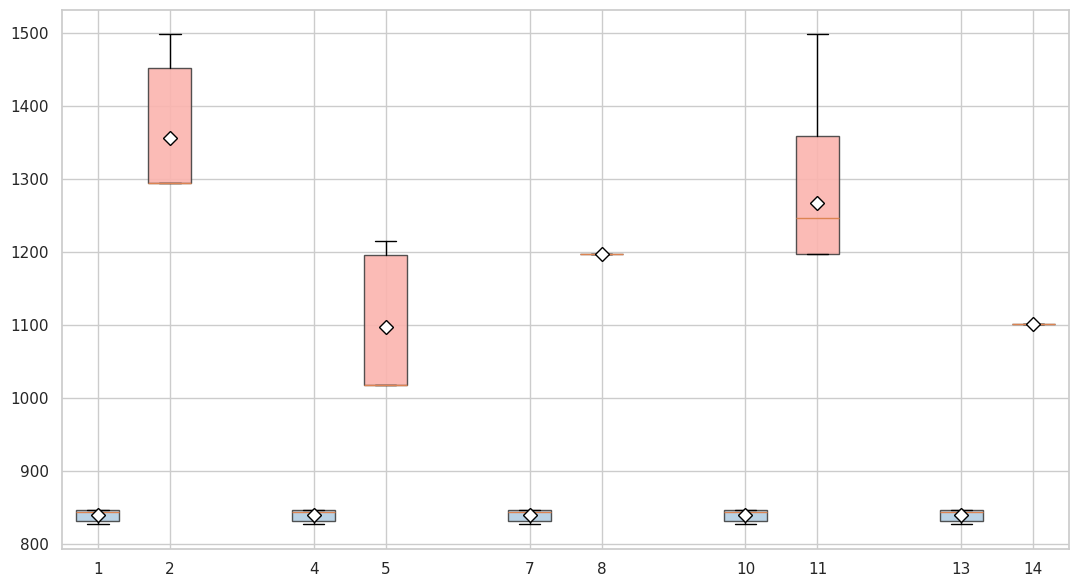

In [27]:
plotar_boxplots_ram_categoria(cat_subconsultas, "RAM em Subconsultas", "Cenários de Subconsulta")

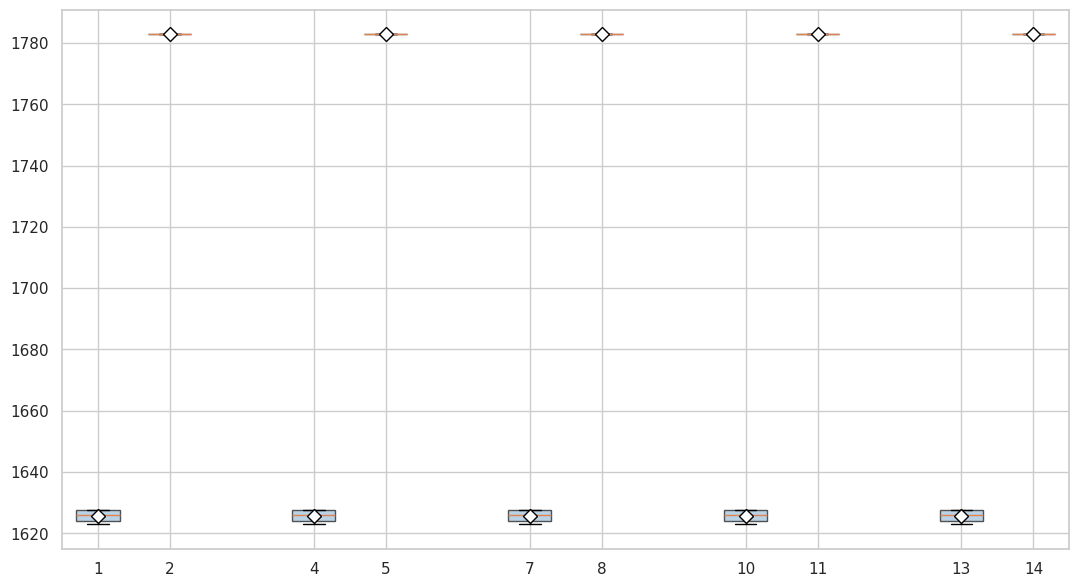

In [28]:
plotar_boxplots_ram_categoria(cat_nao_chave, "RAM em Chaves Não-Primárias", "Cenários de Busca")

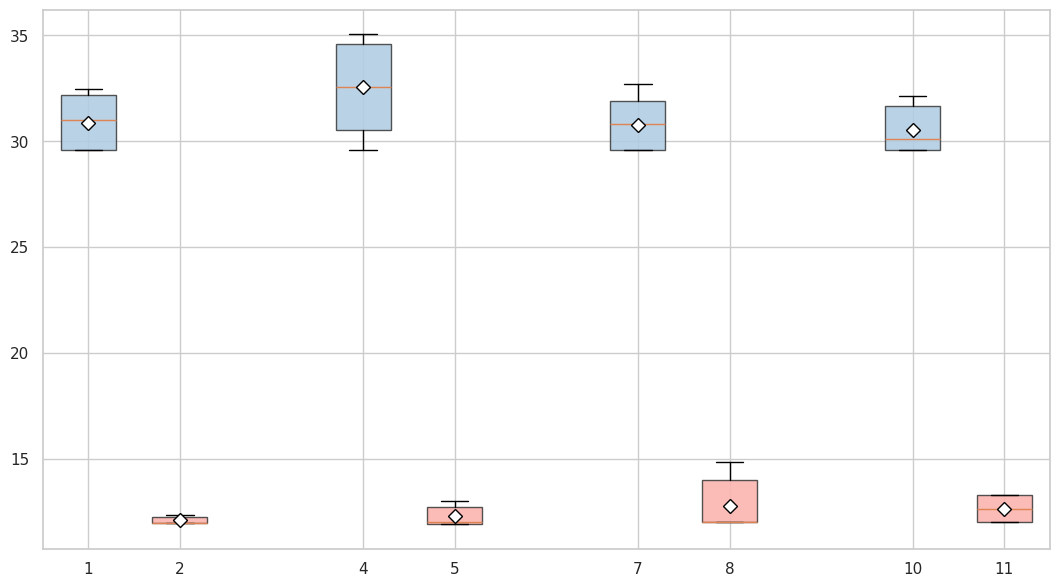

In [29]:
plotar_boxplots_ram_categoria(cat_chave_primaria, "RAM em Chaves Primárias", "Estrutura do Índice Utilizada")

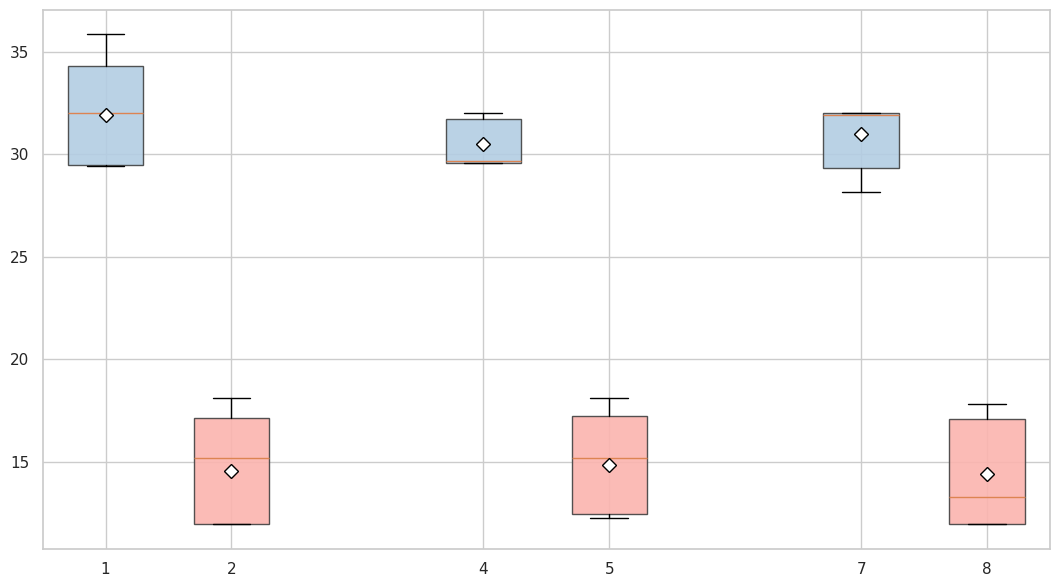

In [30]:
plotar_boxplots_ram_categoria(cat_dml, "RAM em Operações DML", "Operação Executada")

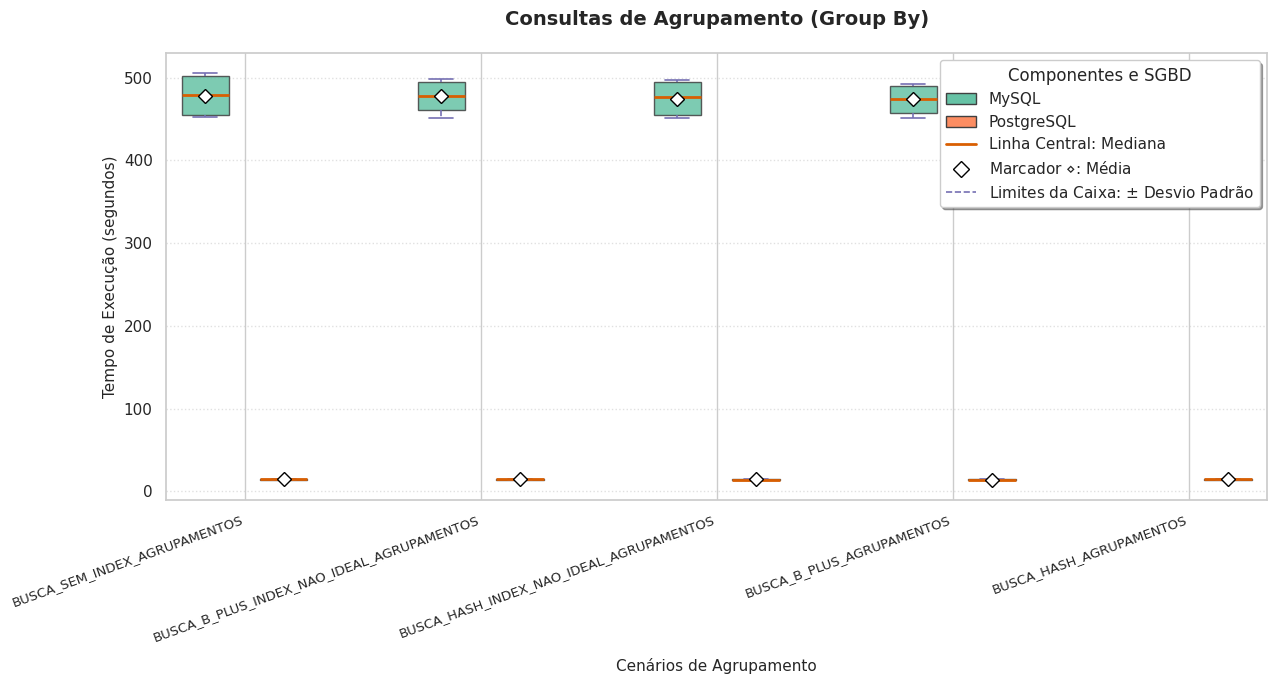

In [31]:
plotar_boxplots_categoria(cat_agrupamentos, "Consultas de Agrupamento (Group By)", "Cenários de Agrupamento")

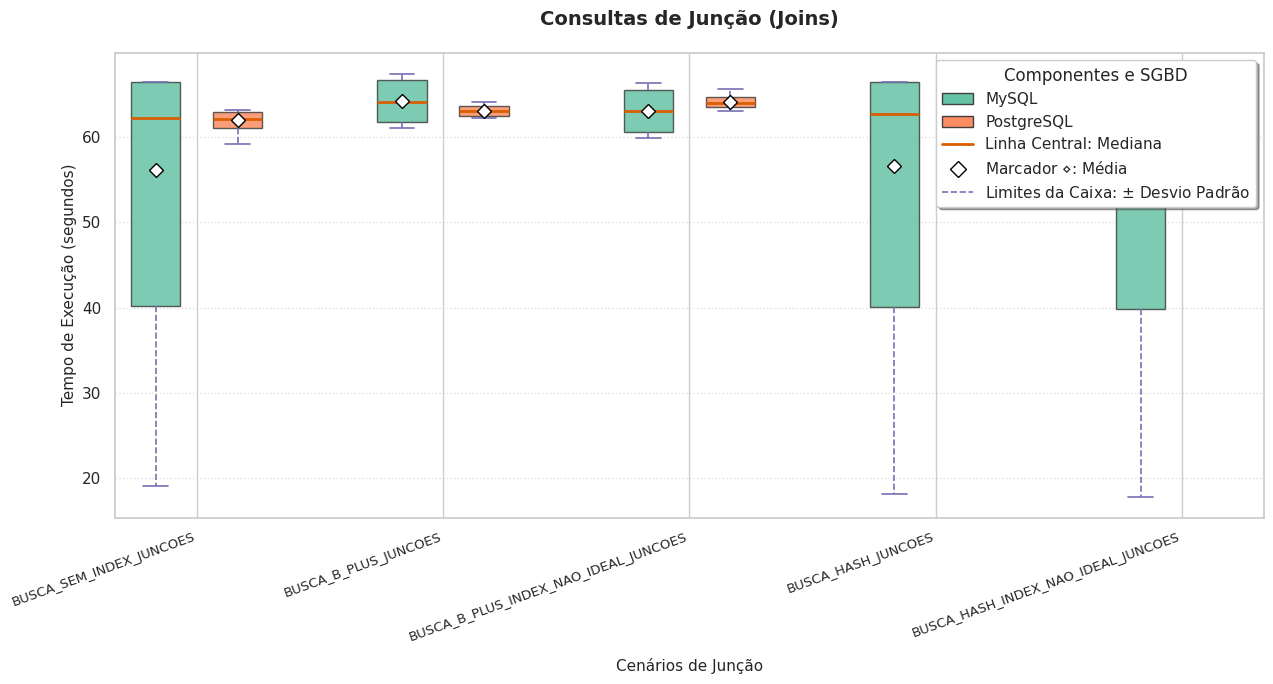

In [32]:
plotar_boxplots_categoria(cat_juncoes, "Consultas de Junção (Joins)", "Cenários de Junção")

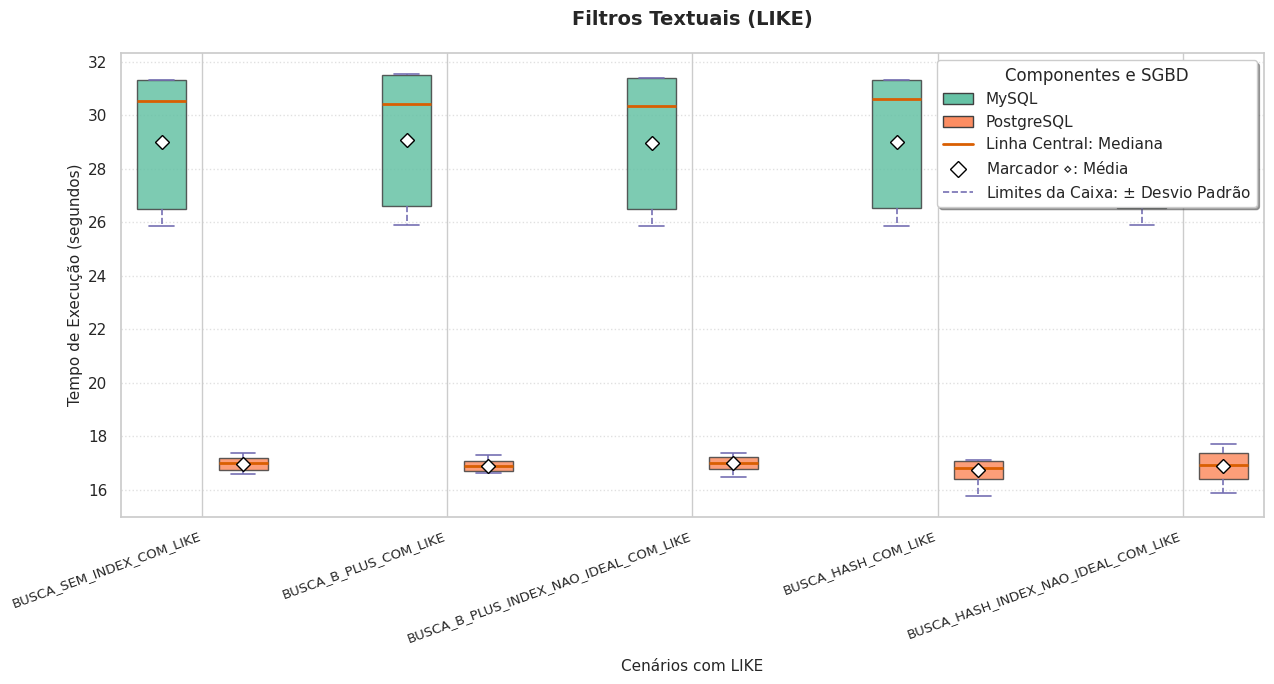

In [33]:
plotar_boxplots_categoria(cat_like, "Filtros Textuais (LIKE)", "Cenários com LIKE")

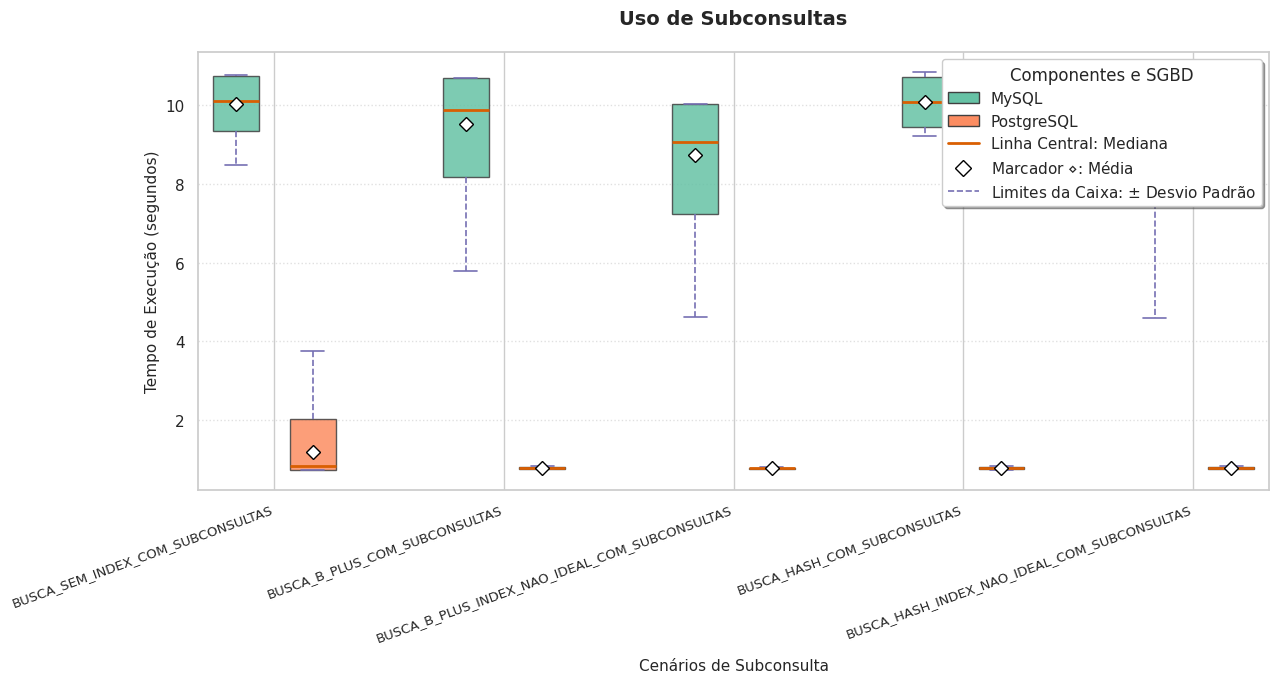

In [34]:
plotar_boxplots_categoria(cat_subconsultas, "Uso de Subconsultas", "Cenários de Subconsulta")

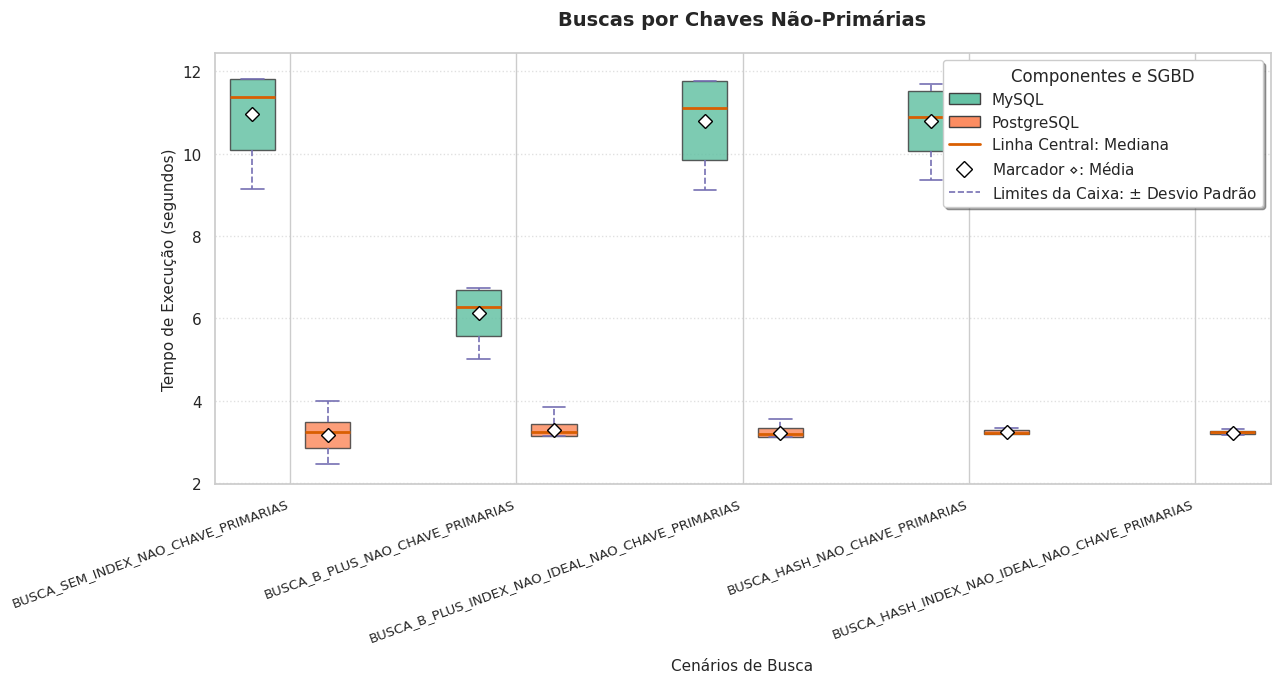

In [35]:
plotar_boxplots_categoria(cat_nao_chave, "Buscas por Chaves Não-Primárias", "Cenários de Busca")

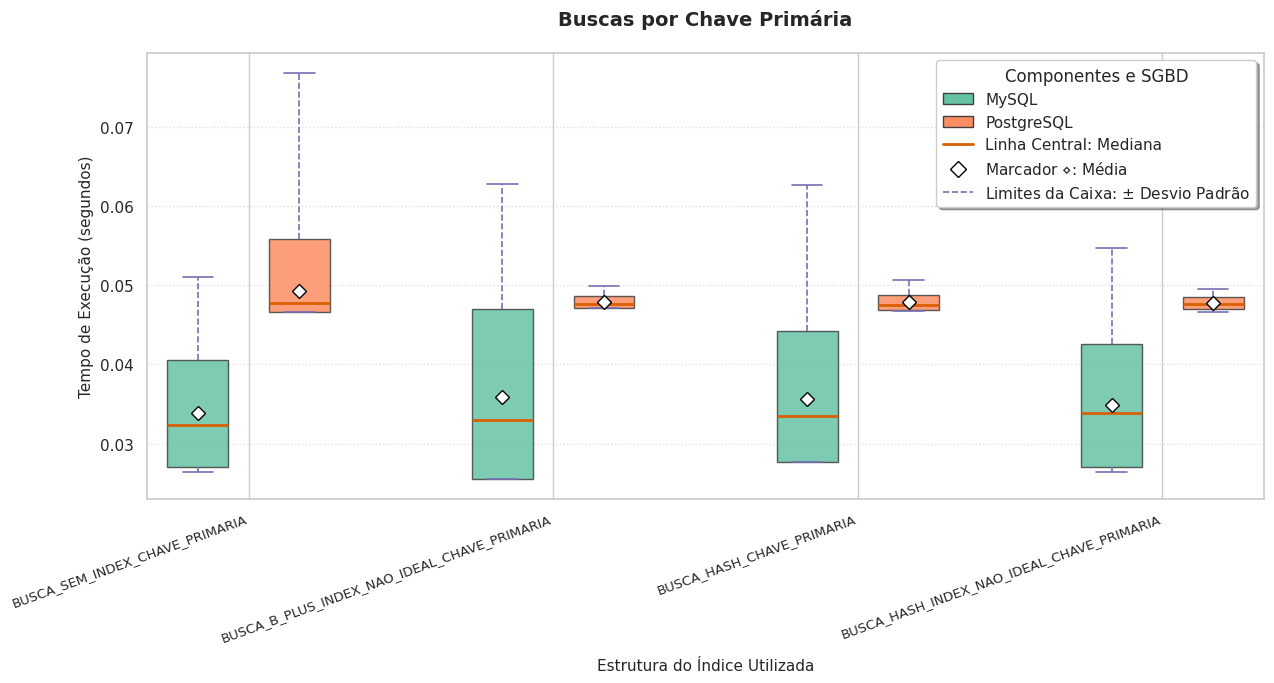

In [36]:
plotar_boxplots_categoria(cat_chave_primaria, "Buscas por Chave Primária", "Estrutura do Índice Utilizada")

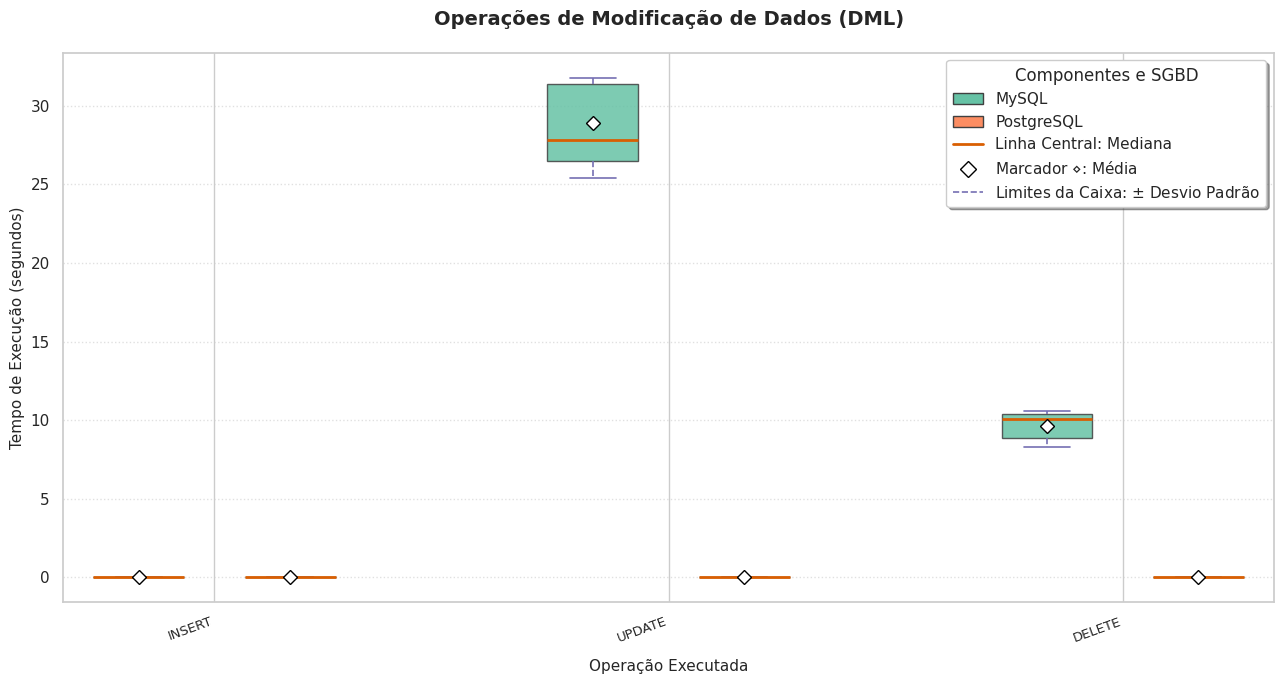

In [37]:
plotar_boxplots_categoria(cat_dml, "Operações de Modificação de Dados (DML)", "Operação Executada")